## Chicago Data Neighborhood Analysis Project 0
##### WILL BRAUCHER

### Exploratory Analysis

#### Data Loading Chicago City Extra Features

In [5]:
import pandas as pd
import geopandas as gpd

df_311 = pd.read_csv("311_Service_Requests_20260128.csv", low_memory=False)
pd.set_option('display.max_columns', None)
df_311.head()

,SR_NUMBER,SR_TYPE,SR_SHORT_CODE,CREATED_DEPARTMENT,OWNER_DEPARTMENT,STATUS,ORIGIN,CREATED_DATE,LAST_MODIFIED_DATE,CLOSED_DATE,STREET_ADDRESS,CITY,STATE,ZIP_CODE,STREET_NUMBER,STREET_DIRECTION,STREET_NAME,STREET_TYPE,DUPLICATE,LEGACY_RECORD,LEGACY_SR_NUMBER,PARENT_SR_NUMBER,COMMUNITY_AREA,WARD,ELECTRICAL_DISTRICT,ELECTRICITY_GRID,POLICE_SECTOR,POLICE_DISTRICT,POLICE_BEAT,PRECINCT,SANITATION_DIVISION_DAYS,CREATED_HOUR,CREATED_DAY_OF_WEEK,CREATED_MONTH,X_COORDINATE,Y_COORDINATE,LATITUDE,LONGITUDE,LOCATION
0,SR25-00139478,Rodent Baiting/Rat Complaint,SGA,NaN,Streets and Sanitation,Completed,Internet,1/27/2025 14:14,1/28/2025 11:35,1/28/2025 11:35,5901 W 63RD PL,Chicago,Illinois,60638.0,5901,W,63RD,PL,False,False,NaN,NaN,64.0,13.0,10.0,B037,1.0,8.0,812.0,45.0,NaN,14,2,1,1138127.275,1861753.026,41.776785,-87.769193,"(41.77678500094007, -87.7691925000019)"
1,SR25-00138680,Graffiti Removal Request,GRAF,Alderman,Streets and Sanitation,Completed,Phone Call,1/27/2025 13:01,1/28/2025 11:35,1/28/2025 11:35,2328 W SCHOOL ST,Chicago,Illinois,60618.0,2328,W,SCHOOL,ST,False,False,NaN,NaN,5.0,32.0,4.0,K014,2.0,19.0,1921.0,19.0,NaN,13,2,1,1160163.169,1921886.769,41.941373,-87.686749,"(41.941373028887455, -87.68674870830223)"
2,SR25-00142639,Building Violation,BBA,NaN,DOB - Buildings,Completed,Internet,1/28/2025 6:36,1/29/2025 13:26,1/28/2025 11:35,1400 S DUSABLE LAKE SHORE DR,Chicago,Illinois,60605.0,1400,S,DUSABLE LAKE SHORE,DR,False,False,NaN,NaN,33.0,4.0,7.0,Q025,3.0,1.0,132.0,25.0,NaN,6,3,1,1178866.782,1893880.207,41.864114,-87.618863,"(41.864114152962905, -87.61886348337268)"
3,SR25-00089753,Garbage Cart Maintenance,SIE,311 City Services,Streets and Sanitation,Completed,Phone Call,1/17/2025 12:31,1/28/2025 11:35,1/28/2025 11:35,8549 S MUSKEGON AVE,Chicago,Illinois,60617.0,8549,S,MUSKEGON,AVE,False,False,NaN,NaN,46.0,10.0,15.0,X042,2.0,4.0,423.0,27.0,NaN,12,6,1,1196721.245,1848642.064,41.739552,-87.554826,"(41.73955200093993, -87.55482600000191)"
4,SR25-00138707,Graffiti Removal Request,GRAF,Alderman,Streets and Sanitation,Completed,Phone Call,1/27/2025 13:04,1/28/2025 11:36,1/28/2025 11:36,3300 N DAMEN AVE,Chicago,Illinois,60618.0,3300,N,DAMEN,AVE,False,False,NaN,NaN,5.0,32.0,4.0,K014,2.0,19.0,1921.0,15.0,NaN,13,2,1,1162344.656,1921953.970,41.941512,-87.678729,"(41.94151200094067, -87.67872900000192)"


In [6]:
df_crime = pd.read_csv("Crimes_-_2001_to_Present_20260128.csv", low_memory=False)
df_crime.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14088087,JK121376,01/20/2026 12:00:00 AM,041XX W WELLINGTON AVE,051A,ASSAULT,AGGRAVATED - HANDGUN,SIDEWALK,True,False,2523,25,31.0,21.0,04A,1148137.0,1919622.0,2026,01/27/2026 03:42:14 PM,41.935391,-87.731003,"(41.935390861, -87.731002633)"
1,14088735,JK122380,01/20/2026 12:00:00 AM,079XX S VERNON AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,624,6,6.0,44.0,14,1180622.0,1852405.0,2026,01/27/2026 03:42:14 PM,41.750255,-87.613689,"(41.750254604, -87.613689346)"
2,14090597,JK121956,01/20/2026 12:00:00 AM,011XX W WILSON AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,COLLEGE / UNIVERSITY - GROUNDS,False,True,1913,19,46.0,3.0,26,1167612.0,1930696.0,2026,01/27/2026 03:42:14 PM,41.965381,-87.659111,"(41.96538061, -87.659110921)"
3,14088405,JK121821,01/20/2026 12:00:00 AM,0000X E 112TH PL,0810,THEFT,OVER $500,APARTMENT,False,False,531,5,9.0,49.0,06,1178433.0,1830383.0,2026,01/27/2026 03:42:14 PM,41.689873,-87.622377,"(41.689873321, -87.62237719)"
4,14090479,JK124126,01/20/2026 12:00:00 AM,020XX N KEELER AVE,1585,SEX OFFENSE,OTHER,RESIDENCE,False,True,2522,25,35.0,20.0,17,1148054.0,1913198.0,2026,01/27/2026 03:42:14 PM,41.917764,-87.731473,"(41.917764415, -87.731473377)"


In [7]:
df_food = pd.read_csv("Food_Inspections_20260128.csv", low_memory=False)
df_food.head()

,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,2630290,"Fatback, Fatback Market, Builders Brew","Fatback, Fatback Market, Builders Brew",3056681.0,Restaurant,Risk 1 (High),222 N LA SALLE ST,CHICAGO,IL,60601.0,01/27/2026,License Re-Inspection,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.886352,-87.632614,"(41.886351604488574, -87.63261394551859)"
1,2630330,"#1 CHOP SUEY RESTAURANT, INC",#1 CHOP SUEY,2695112.0,Restaurant,Risk 1 (High),7342 S STONY ISLAND AVE,CHICAGO,IL,60649.0,01/27/2026,Non-Inspection,No Entry,37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER ...,41.761138,-87.586346,"(41.76113827175918, -87.58634581379175)"
2,2630299,SUBWAY,SUBWAY,1880021.0,Restaurant,Risk 1 (High),2101 E 71ST ST,CHICAGO,IL,60649.0,01/27/2026,Canvass Re-Inspection,Pass,NaN,41.765990,-87.573787,"(41.765990001140594, -87.57378733665412)"
3,2630297,"HALSTED STREET DELI HOLDINGS, LLC - 222 N. LAS...",HALSTED STREET DELI,2857124.0,Restaurant,Risk 1 (High),222 N LA SALLE ST,CHICAGO,IL,60601.0,01/27/2026,Canvass,Out of Business,NaN,41.886352,-87.632614,"(41.886351604488574, -87.63261394551859)"
4,2630292,"Fatback, Fatback Market, Builders Brew","Fatback, Fatback Market, Builders Brew",3056682.0,Restaurant,Risk 3 (Low),222 N LA SALLE ST,CHICAGO,IL,60601.0,01/27/2026,License Re-Inspection,Pass w/ Conditions,NaN,41.886352,-87.632614,"(41.886351604488574, -87.63261394551859)"


In [8]:
df_parks = pd.read_csv("CPD_Parks_20260128.csv", low_memory=False)
df_parks.head()

,the_geom,OBJECTID_1,PARK_NO,PARK,LOCATION,ZIP,ACRES,WARD,PARK_CLASS,LABEL,GISOBJID,WHEELCHR_A,ARCHERY_RA,ARTIFICIAL,BAND_SHELL,BASEBALL_B,BASKETBALL,BASKETBA_1,BEACH,BOAT_LAUNC,BOAT_LAU_1,BOAT_SLIPS,BOCCE_COUR,BOWLING_GR,CASTING_PI,FOOTBALL_S,COMMUNITY_,CONSERVATO,CULTURAL_C,DOG_FRIEND,FITNESS_CE,FITNESS_CO,GALLERY,GARDEN,GOLF_COURS,GOLF_DRIVI,GOLF_PUTTI,GYMNASIUM,GYMNASTIC_,HANDBALL_R,HORSESHOE_,ICESKATING,POOL_INDOO,BASEBALL_J,MOUNTAIN_B,NATURE_CEN,POOL_OUTDO,ZOO,PLAYGROUND,PLAYGROU_1,ROWING_CLU,VOLLEYBALL,SENIOR_CEN,SHUFFLEBOA,SKATE_PARK,SLED_HILL,SPORT_ROLL,SPRAY_FEAT,BASEBALL_S,TENNIS_COU,TRACK,VOLLEYBA_1,WATER_PLAY,WATER_SLID,BOXING_CEN,WETLAND_AR,LAGOON,CRICKET_FI,CLIMBING_W,GAME_TABLE,CAROUSEL,CROQUET,HANDBALL_I,HARBOR,MODELTRAIN,MODELYACHT,NATURE_BIR,MINIGOLF,PERIMETER,Shape_Leng,Shape_Area
0,MULTIPOLYGON (((-87.64817638699884 41.83972833...,1,2,MCGUANE (JOHN),2901 S POPLAR AVE,60608.0,10.3,11,COMMUNITY PARK,McGuane,416,0,0,0,0,0,4,1,0,0,0,0,3,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,3,0,1,3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"2,672.32662667","2,672.32662666","430,341.671424"
1,MULTIPOLYGON (((-87.63286355106932 41.83449527...,2,3,ARMOUR (PHILIP) SQUARE,3309 S SHIELDS AVE,60616.0,9.05,11,COMMUNITY PARK,Armour Sq,423,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,0,3,0,0,1,0,1,0,0,1,0,0,0,0,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"2,484.28300556","2,484.28300556","391,095.834054"
2,MULTIPOLYGON (((-87.63554759375805 41.81257646...,3,4,FULLER (MELVILLE),331 W 45TH ST,60609.0,11.31,3,COMMUNITY PARK,Fuller,448,0,0,0,0,0,6,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,"2,878.42815047","2,878.42815048","497,076.662367"
3,MULTIPOLYGON (((-87.66976347484982 41.80300994...,4,5,CORNELL (PAUL) SQUARE,1809 W 50TH ST,60609.0,8.8,20,COMMUNITY PARK,Cornell Sq,460,0,0,1,0,0,4,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"2,462.60759848","2,462.60759846","385,672.402254"
4,MULTIPOLYGON (((-87.5479925005375 41.744623883...,5,6,RUSSELL (MARTIN) SQUARE,3045 E 83RD ST,60617.0,10.05,10,COMMUNITY PARK,Russell Sq,537,0,0,0,0,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,1,0,1,0,0,2,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"2,777.37593622","2,777.37593622","435,169.113288"


#### ZIP TO COMMUNITY CSV (MADE WITH GEOPANDAS)

In [10]:
zip_ca_crosswalk = pd.read_csv("zip_ca_crosswalk.csv")
zip_ca_crosswalk.head()

,Zip,COMMUNITY_AREA
0,60607,33
1,60607,32
2,60607,31
3,60607,28
4,60607,24


In [11]:
df_food['Zip'] = df_food['Zip'].astype(str).str.zfill(5)
df_parks['ZIP'] = df_parks['ZIP'].astype(str).str.zfill(5)
zip_ca_crosswalk['Zip'] = zip_ca_crosswalk['Zip'].astype(str).str.zfill(5)

To work with neighborhood-level data, I had to map ZIP codes to Chicago’s Community Areas. I downloaded a GeoJSON, processed it in GeoPandas, and exported a CSV to make it easy to merge with other datasets. When loading it, I made sure the ZIP columns were strings with leading zeros preserved so they’d match across food inspections, parks, and other sources.

#### MISSING DATA VALIDATION ON CHICAGO CRIME/311

In [14]:
print(f"\n311 Service Requests:")
print(f"  Total records: {len(df_311):,}")
print(f"  Missing Community Area: {df_311['COMMUNITY_AREA'].isna().sum()} ({df_311['COMMUNITY_AREA'].isna().sum()/len(df_311)*100:.1f}%)")


311 Service Requests:
  Total records: 1,048,575
  Missing Community Area: 832 (0.1%)


In [15]:
print(f"\nCrime Data:")
print(f"  Total records: {len(df_crime):,}")
print(f"  Community Area range: {df_crime['Community Area'].min():.0f} - {df_crime['Community Area'].max():.0f}")
print(f"  Missing Community Area: {df_crime['Community Area'].isna().sum()}")


Crime Data:
  Total records: 110,340
  Community Area range: 1 - 77
  Missing Community Area: 2


Before going into the analysis, I checked the data for missing values in the important geographic field, Community Area. There were 0.1% missing information in the 311 data set, whereas the crime data set had only 2 missing entries out of over 110k. The Community Areas ranged from 1 to 77 as expected. This made me comfortable that the data sets are well-covered and that I can safely aggregate by neighborhoods without worrying about significant missing information.

#### AGGREGATION AND MERGE FOR CHICAGO CRIME/311

In [18]:
df_crime['Community Area'] = pd.to_numeric(df_crime['Community Area'], errors='coerce')

crime_by_ca = df_crime.groupby('Community Area').agg(
    crime_count=('ID', 'count'),
    violent_crimes=('Primary Type', lambda x: x.isin([
        'HOMICIDE', 'ROBBERY', 'ASSAULT', 'BATTERY'
    ]).sum())
).reset_index()


In [19]:
df_311['COMMUNITY_AREA'] = pd.to_numeric(df_311['COMMUNITY_AREA'], errors='coerce')

requests_by_ca = df_311.groupby('COMMUNITY_AREA').agg(
    service_requests=('SR_NUMBER', 'count')
).reset_index()

In [20]:
crime_311_ca = crime_by_ca.merge(
    requests_by_ca,
    left_on='Community Area',
    right_on='COMMUNITY_AREA',
    how='inner'
)
crime_311_ca.fillna(0, inplace=True)
crime_311_ca.head()

,Community Area,crime_count,violent_crimes,COMMUNITY_AREA,service_requests
0,1.0,1727,533,1.0,6695
1,2.0,1603,455,2.0,9221
2,3.0,1923,559,3.0,7501
3,4.0,883,222,4.0,6848
4,5.0,623,106,5.0,6432


In [21]:
crime_311_ca = crime_by_ca.merge(requests_by_ca, left_on='Community Area', right_on='COMMUNITY_AREA', how='inner')
print(f"\nCrime + 311 merged:")
print(f"  Neighborhoods: {len(crime_311_ca)}")


Crime + 311 merged:
  Neighborhoods: 77


I changed the Community Area IDs to numeric in order to ensure that there were no issues arising from any missing values in the data. Next, I grouped the crime data by community area in order to get the total number of crimes, as well as the number of violent crimes, such as homicide, robbery, assault, and battery. The same was done for the 311 service requests in order to get the total number of service requests for each community area. Finally, these two data sets were combined in order to get the data for each community area, making sure that it had both crime data and service request data. Missing values were filled with zero.

### AGGREGATION AND MERGE FOR PARKS AND FOOD DATA

In [24]:
df_parks['ZIP'] = pd.to_numeric(df_parks['ZIP'], errors='coerce')
df_food['Zip'] = pd.to_numeric(df_food['Zip'], errors='coerce')
zip_ca_crosswalk['Zip'] = pd.to_numeric(zip_ca_crosswalk['Zip'], errors='coerce')

df_parks['ACRES'] = pd.to_numeric(df_parks['ACRES'], errors='coerce')

df_parks = df_parks.dropna(subset=['ZIP'])
df_food = df_food.dropna(subset=['Zip'])
zip_ca_crosswalk = zip_ca_crosswalk.dropna(subset=['Zip'])


food_by_zip = df_food.groupby('Zip').agg(
    restaurant_count=('Inspection ID', 'count'),
    high_risk_count=('Risk', lambda x: (x == 'Risk 1 (High)').sum())
).reset_index()

parks_by_zip = df_parks.groupby('ZIP').agg(
    park_acres=('ACRES', 'sum')
).reset_index()

I converted the ZIP codes and park acreage to numeric so that I could group and sum the data correctly. I removed any rows that were missing ZIP codes because those could not be linked to a neighborhood later. After that, I grouped the food inspection data by ZIP to get the total number of restaurants and the number of high-risk restaurants. I did the same with the park data to get the total park acreage per ZIP.

In [26]:
food_parks_zip = food_by_zip.merge(
    parks_by_zip,
    left_on='Zip',
    right_on='ZIP',
    how='left'
)
food_parks_zip.drop(columns='ZIP', inplace=True)
food_parks_zip.fillna(0, inplace=True)

food_parks_ca = food_parks_zip.merge(
    zip_ca_crosswalk[['Zip', 'COMMUNITY_AREA']],
    on='Zip',
    how='inner'
).groupby('COMMUNITY_AREA').agg(
    restaurant_count=('restaurant_count', 'sum'),
    high_risk_count=('high_risk_count', 'sum'),
    park_acres=('park_acres', 'sum')
).reset_index()

food_parks_ca.head()

,COMMUNITY_AREA,restaurant_count,high_risk_count,park_acres
0,1,651,524,284.46
1,2,1497,1252,497.12
2,3,820,682,30.74
3,4,2537,2141,397.05
4,5,3923,3259,372.35


Once I summarized the food inspections and parks data by ZIP, I joined the two datasets together, with each ZIP code containing information for both restaurants and parks. I filled in any missing park data with a zero to ensure that the data remains clean and unaltered. I then used the ZIP code to community area crosswalk to convert the data to the neighborhood level. I used the groupby function to sum up the totals for restaurants, high-risk restaurants, and park acreage, which provided a complete set of features for each community area that matches the crime and 311 data.

#### MERGING TOGETHER THE TWO PREVIOUS DATASETS FOR A CHICAGO FEATURES DF

In [29]:
final_df = crime_311_ca.merge(
    food_parks_ca,
    left_on='Community Area',
    right_on='COMMUNITY_AREA',
    how='left'
)
final_df.fillna(0, inplace=True)
final_df = final_df.drop(columns=['COMMUNITY_AREA_x', 'COMMUNITY_AREA_y'])


final_df.head()

,Community Area,crime_count,violent_crimes,service_requests,restaurant_count,high_risk_count,park_acres
0,1.0,1727,533,6695,651,524,284.46
1,2.0,1603,455,9221,1497,1252,497.12
2,3.0,1923,559,7501,820,682,30.74
3,4.0,883,222,6848,2537,2141,397.05
4,5.0,623,106,6432,3923,3259,372.35


I combined the crime and 311 data with the food and park data at the community area level. I used a left join so that every neighborhood with crime data would be included, even if some food or park data was missing, and I filled those missing values with zero. I also dropped the duplicate COMMUNITY_AREA columns to keep the table clean. The result is a single dataset where each community area has a complete set of features for crime, service requests, restaurants, high-risk restaurants, and park acreage, ready for analysis and modeling.

#### LOADING IN ZILLOW DATA

In [32]:
# Zillow
df_zillow = pd.read_csv("Neighborhood_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df_zillow.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,1/31/2000,2/29/2000,3/31/2000,4/30/2000,5/31/2000,6/30/2000,7/31/2000,8/31/2000,9/30/2000,10/31/2000,11/30/2000,12/31/2000,1/31/2001,2/28/2001,3/31/2001,4/30/2001,5/31/2001,6/30/2001,7/31/2001,8/31/2001,9/30/2001,10/31/2001,11/30/2001,12/31/2001,1/31/2002,2/28/2002,3/31/2002,4/30/2002,5/31/2002,6/30/2002,7/31/2002,8/31/2002,9/30/2002,10/31/2002,11/30/2002,12/31/2002,1/31/2003,2/28/2003,3/31/2003,4/30/2003,5/31/2003,6/30/2003,7/31/2003,8/31/2003,9/30/2003,10/31/2003,11/30/2003,12/31/2003,1/31/2004,2/29/2004,3/31/2004,4/30/2004,5/31/2004,6/30/2004,7/31/2004,8/31/2004,9/30/2004,10/31/2004,11/30/2004,12/31/2004,1/31/2005,2/28/2005,3/31/2005,4/30/2005,5/31/2005,6/30/2005,7/31/2005,8/31/2005,9/30/2005,10/31/2005,11/30/2005,12/31/2005,1/31/2006,2/28/2006,3/31/2006,4/30/2006,5/31/2006,6/30/2006,7/31/2006,8/31/2006,9/30/2006,10/31/2006,11/30/2006,12/31/2006,1/31/2007,2/28/2007,3/31/2007,4/30/2007,5/31/2007,6/30/2007,7/31/2007,8/31/2007,9/30/2007,10/31/2007,11/30/2007,12/31/2007,1/31/2008,2/29/2008,3/31/2008,4/30/2008,5/31/2008,6/30/2008,7/31/2008,8/31/2008,9/30/2008,10/31/2008,11/30/2008,12/31/2008,1/31/2009,2/28/2009,3/31/2009,4/30/2009,5/31/2009,6/30/2009,7/31/2009,8/31/2009,9/30/2009,10/31/2009,11/30/2009,12/31/2009,1/31/2010,2/28/2010,3/31/2010,4/30/2010,5/31/2010,6/30/2010,7/31/2010,8/31/2010,9/30/2010,10/31/2010,11/30/2010,12/31/2010,1/31/2011,2/28/2011,3/31/2011,4/30/2011,5/31/2011,6/30/2011,7/31/2011,8/31/2011,9/30/2011,10/31/2011,11/30/2011,12/31/2011,1/31/2012,2/29/2012,3/31/2012,4/30/2012,5/31/2012,6/30/2012,7/31/2012,8/31/2012,9/30/2012,10/31/2012,11/30/2012,12/31/2012,1/31/2013,2/28/2013,3/31/2013,4/30/2013,5/31/2013,6/30/2013,7/31/2013,8/31/2013,9/30/2013,10/31/2013,11/30/2013,12/31/2013,1/31/2014,2/28/2014,3/31/2014,4/30/2014,5/31/2014,6/30/2014,7/31/2014,8/31/2014,9/30/2014,10/31/2014,11/30/2014,12/31/2014,1/31/2015,2/28/2015,3/31/2015,4/30/2015,5/31/2015,6/30/2015,7/31/2015,8/31/2015,9/30/2015,10/31/2015,11/30/2015,12/31/2015,1/31/2016,2/29/2016,3/31/2016,4/30/2016,5/31/2016,6/30/2016,7/31/2016,8/31/2016,9/30/2016,10/31/2016,11/30/2016,12/31/2016,1/31/2017,2/28/2017,3/31/2017,4/30/2017,5/31/2017,6/30/2017,7/31/2017,8/31/2017,9/30/2017,10/31/2017,11/30/2017,12/31/2017,1/31/2018,2/28/2018,3/31/2018,4/30/2018,5/31/2018,6/30/2018,7/31/2018,8/31/2018,9/30/2018,10/31/2018,11/30/2018,12/31/2018,1/31/2019,2/28/2019,3/31/2019,4/30/2019,5/31/2019,6/30/2019,7/31/2019,8/31/2019,9/30/2019,10/31/2019,11/30/2019,12/31/2019,1/31/2020,2/29/2020,3/31/2020,4/30/2020,5/31/2020,6/30/2020,7/31/2020,8/31/2020,9/30/2020,10/31/2020,11/30/2020,12/31/2020,1/31/2021,2/28/2021,3/31/2021,4/30/2021,5/31/2021,6/30/2021,7/31/2021,8/31/2021,9/30/2021,10/31/2021,11/30/2021,12/31/2021,1/31/2022,2/28/2022,3/31/2022,4/30/2022,5/31/2022,6/30/2022,7/31/2022,8/31/2022,9/30/2022,10/31/2022,11/30/2022,12/31/2022,1/31/2023,2/28/2023,3/31/2023,4/30/2023,5/31/2023,6/30/2023,7/31/2023,8/31/2023,9/30/2023,10/31/2023,11/30/2023,12/31/2023,1/31/2024,2/29/2024,3/31/2024,4/30/2024,5/31/2024,6/30/2024,7/31/2024,8/31/2024,9/30/2024,10/31/2024,11/30/2024,12/31/2024,1/31/2025,2/28/2025,3/31/2025,4/30/2025,5/31/2025,6/30/2025,7/31/2025,8/31/2025,9/30/2025,10/31/2025,11/30/2025,12/31/2025
0,112345,0,Maryvale,neighborhood,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,68538.92061,68754.04514,69040.65373,69667.45376,70360.92179,70997.81505,71629.14153,72270.60288,72965.55136,73603.61132,74216.50937,74814.24812,75425.22105,76041.34089,76671.12602,77267.97823,77825.03708,78319.54467,78773.08928,79197.05406,79679.57835,80204.90442,80769.47261,81256.59275,81664.56731,82057.17006,82482.01331,82909.78806,83275.78527,83639.43803,84033.98754,84491.84003,84903.19666,85295.45773,85640.2591,85993.09631,86318.79065,86645.61592,86921.19146,87266.50149,87629.48507,88039.6329,88427.13387,88847.13723,89370.14865,89957.62597,90510.92306,90967.07019,91333.35434,91783.25181,9.236925e+04,9.301532e+04,9.376693

#### FILTERING AND CLEANING ZILLOW DATA

In [34]:
df_chicago = df_zillow[df_zillow['City'] == 'Chicago'].copy()
df_chicago = df_chicago[df_chicago['RegionType'] == 'neighborhood']
last_year_cols = df_chicago.columns[-12:] 
df_chicago_last_year = df_chicago[['RegionName'] + list(last_year_cols)].copy()
df_chicago_last_year.head()

,RegionName,1/31/2025,2/28/2025,3/31/2025,4/30/2025,5/31/2025,6/30/2025,7/31/2025,8/31/2025,9/30/2025,10/31/2025,11/30/2025,12/31/2025
42,Lake View,388653.7317,390855.4950,392318.4855,392375.6340,392370.3704,392775.3090,394464.8336,396769.8979,400150.1197,403772.5317,407250.0463,410201.9973
89,West Ridge,265127.2362,265062.1979,264838.2457,263676.3514,262726.6341,262652.6693,263860.7405,265590.2824,267007.9235,267987.1475,268912.6952,270260.8219
98,Little Village,209851.3610,211511.4162,212213.1647,212568.2293,212009.1009,210903.4577,209924.6097,208447.8657,206980.1770,204948.0559,203665.6818,202768.8923
100,Logan Square,468950.0476,470437.8574,472238.0100,473609.7922,474238.1093,474535.7695,475732.0920,477469.2446,480488.6013,484097.0457,488542.7729,492255.8432
124,Lincoln Park,588532.4127,591157.1220,593017.1704,592631.7601,591857.3305,591810.3516,593461.3010,595303.7463,598927.7940,604374.6100,611135.8081,617578.9209


I loaded the Zillow neighborhood-level home value data, which provides the ZHVI (Zillow Home Value Index) values for single-family homes and condos/townhomes in U.S. neighborhoods on a monthly basis from January 2000 to December 2025. This data provided me with a long time series of home values, which I will match with our Chicago community area features for analysis or modeling.

#### LOADING IN AIRBNB DATA

In [37]:
df_listings = pd.read_csv("listings.csv", low_memory=False)
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2384,https://www.airbnb.com/rooms/2384,20250922033851,2025-09-22,city scrape,Hyde Park - Walk to University of Chicago,Solo Hyde Park visitors are invited to enjoy t...,The apartment is less than one block from beau...,https://a0.muscache.com/pictures/hosting/Hosti...,2613,https://www.airbnb.com/users/show/2613,Rebecca,2008-08-29,NaN,"If you’re not familiar with Chicago, I can hel...",within an hour,100%,81%,f,https://a0.muscache.com/im/pictures/user/8bb47...,https://a0.muscache.com/im/pictures/user/8bb47...,Hyde Park,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Hyde Park,NaN,41.787900,-87.587800,Private room in condo,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Dishes and silverware"", ""Free street parking...",$119.00,3,90,3.0,4.0,90.0,90.0,3.0,90.0,NaN,t,13,43,73,348,2025-09-22,257,10,0,84,20,60,7140.0,2015-01-09,2025-08-07,4.99,4.98,4.99,4.99,4.98,4.95,4.93,R17000015609,f,1,0,1,0,1.97
1,7126,https://www.airbnb.com/rooms/7126,20250922033851,2025-09-22,city scrape,Tiny Studio Apartment 94 Walk Score,A very small studio in a wonderful neighborhood.,"Ukrainian Village was just named ""Hottest Neig...",https://a0.muscache.com/pictures/51073/16c81c7...,17928,https://www.airbnb.com/users/show/17928,Sarah,2009-05-19,"Chicago, IL",We live in Chicago. We love to travel and see ...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/17928/profile...,https://a0.muscache.com/im/users/17928/profile...,Ukrainian Village,1.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,West Town,NaN,41.901660,-87.680210,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Dishes and silverware"", ""Free street parking...",$89.00,2,60,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,6,23,39,302,2025-09-22,595,47,3,48,52,255,22695.0,2009-07-03,2025-09-01,4.73,4.85,4.58,4.91,4.88,4.90,4.77,R24000114046,f,1,1,0,0,3.01
2,10945,https://www.airbnb.com/rooms/10945,20250922033851,2025-09-24,city scrape,The Biddle House (#1),Beautiful first floor apartment in Historic Ol...,NaN,https://a0.muscache.com/pictures/58d1a420-a24b...,33004,https://www.airbnb.com/users/show/33004,At Home Inn,2009-08-21,"Chicago, IL","Hi, we're Bob and Liz Biddle, long time Chicag...",within an hour,95%,89%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Old Town,9.0,87.0,"['email', 'phone', 'work_email']",t,t,NaN,Lincoln Park,NaN,41.911960,-87.639810,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Wifi"", ""Lake access"", ""Free washer \u2013 In...",$203.00,4,120,2.0,4.0,1125.0,1125.0,4.0,1125.0,NaN,t,2,26,50,325

#### CLEANING AIRBNB DATA

In [39]:
airbnb = df_listings[[
    'neighbourhood_cleansed',
    'price',
    'accommodates',
    'beds',
    'room_type',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    'review_scores_rating'
]].copy()

airbnb['price'] = (
    airbnb['price']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

airbnb['entire_home'] = (airbnb['room_type'] == 'Entire home/apt').astype(int)

airbnb['neighbourhood_cleansed'] = airbnb['neighbourhood_cleansed'].str.strip().str.title()
df_chicago_last_year['RegionName'] = df_chicago_last_year['RegionName'].str.strip().str.title()

I filtered the Airbnb listings to only keep the relevant features for analysis: neighborhood, price, number of beds and guests, room type, estimated occupancy and revenue, and review scores. The price column was cleaned by removing $ and , characters and converting it to a numeric float for calculations. I added a binary column entire_home to flag listings that are entire homes or apartments. Finally, I standardized neighborhood names in both the Airbnb and Zillow datasets by stripping whitespace and converting to title case, ensuring consistency for future merges.

#### AIRBNB NEIGHBORHOOD AGGREGATION

In [42]:
airbnb_nbhd = (
    airbnb
    .dropna(subset=['neighbourhood_cleansed'])
    .groupby('neighbourhood_cleansed')
    .agg(
        airbnb_listings=('price', 'count'),
        avg_price=('price', 'mean'),
        avg_accommodates=('accommodates', 'mean'),
        avg_beds=('beds', 'mean'),
        pct_entire_home=('entire_home', 'mean'),
        avg_occupancy=('estimated_occupancy_l365d', 'mean'),
        avg_revenue=('estimated_revenue_l365d', 'mean'),
        avg_rating=('review_scores_rating', 'mean')
    )
    .reset_index()
    .rename(columns={'neighbourhood_cleansed': 'RegionName'})
)

I aggregated the Airbnb dataset from individual listings to the neighborhood level by computing summary metrics for each neighborhood. For each neighborhood, I calculated the number of listings, average price, average accommodates and beds, percentage of listings that are entire homes, average occupancy, average revenue, and average guest rating. The column named “neighbourhood_cleansed” was renamed “RegionName” to have it merge with Zillow’s neighborhood information.

#### ZILLOW FURTHER FILTERING & CLEANING

In [45]:
zillow = df_chicago_last_year.copy()

date_cols = zillow.columns.drop('RegionName')

zillow['zhvi_mean_last_year'] = zillow[date_cols].mean(axis=1)
zillow['zhvi_change_last_year'] = zillow[date_cols].iloc[:, -1] - zillow[date_cols].iloc[:, 0]

I duplicated the Zillow data and reduced the 12 monthly ZHVI values into two important features for each neighborhood. The features are as follows: zhvi_mean_last_year contains the average value of homes over the year, and zhvi_change_last_year contains the absolute change in value from the first month to the last month.

#### COMBINING THE AIRBNB AND ZILLOW DATASETS

In [48]:
zillow = zillow[['RegionName', 'zhvi_mean_last_year', 'zhvi_change_last_year']]
nbhd_combined = zillow.merge(
    airbnb_nbhd,
    on='RegionName',
    how='inner'
)
nbhd_combined.head()

,RegionName,zhvi_mean_last_year,zhvi_change_last_year,airbnb_listings,avg_price,avg_accommodates,avg_beds,pct_entire_home,avg_occupancy,avg_revenue,avg_rating
0,Lake View,396829.871008,21548.2656,518,246.532819,5.051002,2.729730,0.859745,122.783242,26931.030888,4.827120
1,West Ridge,265641.912133,5133.5857,104,128.509615,4.419643,2.413462,0.732143,78.366071,10430.807692,4.636400
2,Logan Square,477716.265475,23305.7956,426,182.814554,4.747300,2.549296,0.792657,114.563715,19695.117371,4.846226
3,Lincoln Park,597482.360633,29046.5082,269,281.687732,5.293515,2.855019,0.904437,115.689420,28259.899628,4.812016
4,Irving Park,405994.953158,24329.5590,163,144.214724,4.275132,2.411043,0.767196,101.153439,14779.957055,4.866023


I used an inner join to combine the Zillow and Airbnb data at the neighborhood level. This way, each neighborhood will have information about both home value trends and short-term rental characteristics. Using an inner join will only include neighborhoods that are present in both datasets.

#### MAPPING FOR THE CHICAGO NEIGHBORHOOD TO COMMUNITY AREA NUMBER

In [51]:
# Chicago neighborhoods mapped to their community area number
neighborhood_to_ca = {
    # Far North Side
    "Rogers Park": 1, "Loyola": 1,
    "West Ridge": 2, "Nortown": 2, "Peterson Park": 2, "Rosehill": 2, "West Rogers Park": 2,
    "Uptown": 3, "Clarendon Park": 3, "Buena Park": 3, "New Chinatown": 3, "Sheridan Park": 3,
    "Lincoln Square": 4, "Bowmanville": 4, "Budlong Woods": 4, "Ravenswood": 4, "Ravenswood Gardens": 4,
    "Edison Park": 9,
    "Norwood Park": 10, "Big Oaks": 10, "Old Norwood": 10, "Oriole Park": 10, "Union Ridge": 10,
    "Jefferson Park": 11, "Gladstone Park": 11,
    "Forest Glen": 12, "Edgebrook": 12, "Middle Edgebrook": 12, "Sauganash": 12, "Wildwood": 12,
    "North Park": 13, "Hollywood Park": 13, "Pulaski Park": 13,
    "Albany Park": 14, "Mayfair": 14, "North Mayfair": 14, "Ravenswood Manor": 14,
    "O'Hare": 76, "Schorsch Forest View": 76,
    "Edgewater": 77, "Andersonville": 77, "Edgewater Glen": 77, "Epic": 77, "Lakewood/Balmoral": 77,

    # North Side
    "North Center": 5, "Northcenter": 5, "Roscoe Village": 5, "Saint Ben's": 5,
    "Lake View": 6, "Lakeview East": 6, "North Halsted": 6, "West Lakeview": 6, "Wrigleyville": 6,
    "Lincoln Park": 7, "DePaul": 7, "Old Town Triangle": 7, "Park West": 7, "Ranch Triangle": 7,
    "Sheffield Neighbors": 7, "Wrightwood Neighbors": 7,
    "Avondale": 20, "Jackowo": 20, "Wacławowo": 20,
    "Logan Square": 22, "Bucktown": 22, "Palmer Square": 22,

    # Northwest Side
    "Portage Park": 15, "Six Corners": 15,
    "Irving Park": 16, "Kilbourn Park": 16, "Old Irving Park": 16, "The Villa": 16,
    "Dunning": 17, "Belmont Heights": 17, "Belmont Terrace": 17, "Irving Woods": 17, "Schorsch Village": 17,
    "Montclare": 18,
    "Belmont Cragin": 19, "Brickyard": 19, "Cragin": 19, "Hanson Park": 19,
    "Hermosa": 20, "Belmont Gardens": 20, "Kelvyn Park": 20,

    # Central / Near North / Near South Side
    "Near North Side": 8, "Cabrini-Green": 8, "Dearborn Parkway": 8, "The Gold Coast": 8, 
    "Goose Island": 8, "Magnificent Mile": 8, "Old Town": 8, "River North": 8, 
    "River West": 8, "State Parkway": 8, "Streeterville": 8,
    "Loop": 49, "The Loop": 49, "New Eastside": 49, "Printer’s Row": 49, "South Loop": 49,
    "Near South Side": 26, "Dearborn Park": 26, "Museum Park": 26, "Central Station": 26, "Prairie Avenue Historic District": 26,

    # West / Near West Side
    "Humboldt Park": 23,
    "West Town": 24, "East Village": 24, "Noble Square": 24, "Ukrainian Village": 24, "Smith Park": 24, "Wicker Park": 24,
    "Austin": 25, "Galewood": 25, "The Island": 25,
    "West Garfield Park": 72,
    "East Garfield Park": 73, "Fifth City": 73,
    "Near West Side": 28, "Columbus Circle": 28, "Greektown": 28, "Little Italy": 28, "Medical Center": 28, "Tri-Taylor": 28, "Fulton River District": 28, "University Village": 28,
    "North Lawndale": 29,
    "South Lawndale": 42, "Little Village": 42, "Marshall Square": 42,
    "Lower West Side": 23, "Heart of Chicago": 23, "Pilsen": 23,

    # Southwest Side
    "Garfield Ridge": 36, "Le Claire Courts": 36, "Sleepy Hollow": 36, "Vittum Park": 36,
    "Archer Heights": 37,
    "Brighton Park": 38,
    "McKinley Park": 39,
    "New City": 41, "Back of the Yards": 41, "Canaryville": 41,
    "West Elsdon": 42,
    "Gage Park": 43,
    "Clearing": 44, "Chrysler Village": 44,
    "West Lawn": 45, "Ford City": 45,
    "Chicago Lawn": 46, "Lithuanian Plaza": 46, "Marquette Park": 46,
    "West Englewood": 47,
    "Englewood": 48, "Hamilton Park": 48,

    # South Side
    "Armour Square": 28, "Chinatown": 28, "Wentworth Gardens": 28,
    "Douglas": 30, "Bronzeville": 30, "Groveland Park": 30, "Lake Meadows": 30, "Prairie Shores": 30, "South Commons": 30,
    "Oakland": 32,
    "Fuller Park": 39,
    "Grand Boulevard": 38,
    "Kenwood": 51,
    "Washington Park": 52,
    "Hyde Park": 63,
    "Woodlawn": 64,
    "South Shore": 54, "Jackson Park Highlands": 54,
    "Bridgeport": 40,
    "Greater Grand Crossing": 69, "Grand Crossing": 69, "Park Manor": 69,

    # Far Southwest Side
    "Ashburn": 72, "Ashburn Estates": 72, "Beverly View": 72, "Crestline": 72, "Parkview": 72, "Scottsdale": 72, "Wrightwood": 72,
    "Auburn Gresham": 73, "Gresham": 73,
    "Beverly": 74, "West Beverly": 74,
    "Washington Heights": 75, "Brainerd": 75, "Longwood Manor": 75,
    "Mount Greenwood": 76, "Talley’s Corner": 76,
    "Morgan Park": 75, "Beverly Woods": 75, "Kennedy Park": 75, "West Morgan Park": 75,

    # Far South Side
    "Chatham": 48, "West Chesterfield": 48,
    "Avalon Park": 57, "Marynook": 57, "Stony Island Park": 57,
    "South Chicago": 46,
    "Burnside": 59,
    "Calumet Heights": 60, "Pill Hill": 60,
    "Roseland": 56, "Fernwood": 56, "Princeton Park": 56,
    "Pullman": 55, "Cottage Grove Heights": 55,
    "South Deering": 61, "Jeffrey Manor": 61,
    "East Side": 58,
    "West Pullman": 75,
    "Riverdale": 54, "Altgeld Gardens": 54, "Eden Green": 54, "Golden Gate": 54,
    "Hegewisch": 62
}


I created a dictionary that maps neighborhood names (e.g., “Lake View,” “Logan Square”) to official Chicago community area numbers. When I apply this dictionary, I'll be able to assign a CommunityArea code to our neighborhood level Zillow and Airbnb data, matching it to the geography I am using for other datasets like crime, 311, food, and parks.

In [53]:
nbhd_combined['CommunityArea'] = nbhd_combined['RegionName'].map(neighborhood_to_ca)

#### AGGREGATING BASED OFF OF THE COMMUNITY AREA FROM THE NEIGHBORHOOD DATA

In [55]:
ca_agg = nbhd_combined.groupby('CommunityArea').agg(
    zhvi_mean=('zhvi_mean_last_year', 'mean'),
    zhvi_change=('zhvi_change_last_year', 'mean'),
    airbnb_listings=('airbnb_listings', 'sum'),
    avg_price=('avg_price', 'mean'),
    avg_accommodates=('avg_accommodates', 'mean'),
    avg_beds=('avg_beds', 'mean'),
    pct_entire_home=('pct_entire_home', 'mean'),
    avg_occupancy=('avg_occupancy', 'mean'),
    avg_revenue=('avg_revenue', 'mean'),
    avg_rating=('avg_rating', 'mean')
).reset_index()

I aggregated the merged neighborhood-level data up to the community area level. For Zillow, I averaged ZHVI statistics across neighborhoods, while for Airbnb, I summed listing counts and averaged prices, occupancy, and ratings. 

#### FINAL DATASET MERGED TOGETHER

In [58]:
final_merged_df = final_df.merge(ca_agg, left_on='Community Area', right_on='CommunityArea', how='inner')
final_merged_df = final_merged_df.drop(columns=['CommunityArea'])
final_merged_df.head()

,Community Area,crime_count,violent_crimes,service_requests,restaurant_count,high_risk_count,park_acres,zhvi_mean,zhvi_change,airbnb_listings,avg_price,avg_accommodates,avg_beds,pct_entire_home,avg_occupancy,avg_revenue,avg_rating
0,1.0,1727,533,6695,651,524,284.46,239771.264517,6618.9143,159,129.540881,3.684211,1.924528,0.707602,105.970760,13387.993711,4.645742
1,2.0,1603,455,9221,1497,1252,497.12,265641.912133,5133.5857,104,128.509615,4.419643,2.413462,0.732143,78.366071,10430.807692,4.636400
2,3.0,1923,559,7501,820,682,30.74,305058.228483,6089.9439,164,158.286585,3.723757,1.926829,0.817680,122.441989,18279.237805,4.774214
3,4.0,883,222,6848,2537,2141,397.05,468545.322900,9071.3757,108,134.703704,3.547826,1.879630,0.904348,132.730435,17928.009259,4.820442
4,5.0,623,106,6432,3923,3259,372.35,682654.389017,27721.8621,126,193.031746,5.169118,2.666667,0.919118,103.294118,17412.769841,4.853089


In [59]:
print(f"\nFinal dataset:")
print(f"  Total neighborhoods: {len(final_merged_df)}")


Final dataset:
  Total neighborhoods: 53


I joined the table of core features (crime, 311, food, and parks) with the table of market features (Zillow and Airbnb) using the community area ID. I then dropped the duplicate column of Community Area, which resulted in a single table with all the predictors and target variables.

#### SUMMARY STATISTICS

In [62]:
final_merged_df.describe()

,Community Area,crime_count,violent_crimes,service_requests,restaurant_count,high_risk_count,park_acres,zhvi_mean,zhvi_change,airbnb_listings,avg_price,avg_accommodates,avg_beds,pct_entire_home,avg_occupancy,avg_revenue,avg_rating
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,37.849057,1219.226415,342.603774,16414.226415,1242.415094,992.320755,519.215126,300640.254927,8157.100011,98.169811,150.059814,4.627136,2.450285,0.719083,87.657442,12358.815789,4.763525
std,23.318362,1051.423900,297.215109,54418.558321,1000.362942,818.355358,431.801447,127325.757108,11230.916742,148.666862,52.570185,1.371001,0.791705,0.207464,27.227861,5977.268233,0.123156
min,1.000000,109.000000,35.000000,714.000000,84.000000,69.000000,30.740000,123533.835650,-16866.129600,1.000000,60.285714,1.333333,0.500000,0.000000,29.000000,2752.000000,4.430000
25%,16.000000,465.000000,132.000000,3615.000000,592.000000,473.000000,219.430000,199926.109417,2124.855300,11.000000,117.500000,3.925287,1.926829,0.604167,63.333333,7681.263158,4.690323
50%,40.000000,883.000000,265.000000,6342.000000,916.000000,682.000000,397.050000,282992.204425,6846.721300,33.000000,135.088889,4.419643,2.400000,0.767196,92.601852,12474.000000,4.805000
75%,57.000000,1661.000000,457.000000,8133.000000,1525.000000,1242.000000,654.527000,385108.040933,14474.321100,113.000000,166.833333,5.169118,2.730978,0.857143,109.169731,16797.523810,4.842857
max,77.000000,4941.000000,1377.000000,350743.000000,4351.000000,3475.000000,2114.190000,682654.389017,45703.034800,704.000000,289.870739,8.400000,4.800000,1.000000,132.730435,28259.899628,4.950000


The final dataset has 53 Chicago community areas with all features included. It combines crime, service requests, restaurants, high-risk locations, and park acres with Zillow data on home values and Airbnb data on listings, prices, occupancy, revenue, and ratings. Everything is cleaned and aggregated to the community area level so it is ready for analysis.

#### FINAL CLEAN TO MAKE IT LOOK NICE

In [65]:
final_clean_df = final_merged_df.rename(columns={
    'Community Area': 'community_area',
    'crime_count': 'total_crimes',
    'violent_crimes': 'violent_crimes',
    'service_requests': 'service_requests',
    'restaurant_count': 'restaurant_count',
    'high_risk_count': 'high_risk_businesses',
    'park_acres': 'park_acres',
    'zhvi_mean': 'avg_home_value',
    'zhvi_change': 'home_value_change',
    'airbnb_listings': 'airbnb_listings_count',
    'avg_price': 'airbnb_avg_price',
    'avg_accommodates': 'airbnb_avg_accommodates',
    'avg_beds': 'airbnb_avg_beds',
    'pct_entire_home': 'pct_airbnb_entire_home',
    'avg_occupancy': 'airbnb_avg_occupancy',
    'avg_revenue': 'airbnb_avg_revenue',
    'avg_rating': 'airbnb_avg_rating'
})

final_clean_df.head()

,community_area,total_crimes,violent_crimes,service_requests,restaurant_count,high_risk_businesses,park_acres,avg_home_value,home_value_change,airbnb_listings_count,airbnb_avg_price,airbnb_avg_accommodates,airbnb_avg_beds,pct_airbnb_entire_home,airbnb_avg_occupancy,airbnb_avg_revenue,airbnb_avg_rating
0,1.0,1727,533,6695,651,524,284.46,239771.264517,6618.9143,159,129.540881,3.684211,1.924528,0.707602,105.970760,13387.993711,4.645742
1,2.0,1603,455,9221,1497,1252,497.12,265641.912133,5133.5857,104,128.509615,4.419643,2.413462,0.732143,78.366071,10430.807692,4.636400
2,3.0,1923,559,7501,820,682,30.74,305058.228483,6089.9439,164,158.286585,3.723757,1.926829,0.817680,122.441989,18279.237805,4.774214
3,4.0,883,222,6848,2537,2141,397.05,468545.322900,9071.3757,108,134.703704,3.547826,1.879630,0.904348,132.730435,17928.009259,4.820442
4,5.0,623,106,6432,3923,3259,372.35,682654.389017,27721.8621,126,193.031746,5.169118,2.666667,0.919118,103.294118,17412.769841,4.853089


I renamed the columns to cleaner, more descriptive names that make sense as features in my dataset. This way it’s easier for me to read in my code and to explain in my write-up, like using avg_home_value instead of zhvi_mean.

#### FEATURE ENGINEERING

In [68]:
final_clean_df['violent_crime_rate'] = (
    final_clean_df['violent_crimes'] / final_clean_df['total_crimes'] * 100
)

final_clean_df['food_safety_ratio'] = (
    (final_clean_df['restaurant_count'] - final_clean_df['high_risk_businesses']) 
    / final_clean_df['restaurant_count'] * 100
)

final_clean_df['park_acres_per_1000_residents'] = (
    final_clean_df['park_acres'] / final_clean_df['restaurant_count'] * 1000
)

final_clean_df['airbnb_market_penetration'] = (
    final_clean_df['airbnb_listings_count'] / final_clean_df['restaurant_count']
)

final_clean_df['home_value_growth_rate'] = (
    final_clean_df['home_value_change'] / final_clean_df['avg_home_value'] * 100
)

final_clean_df['service_request_density'] = (
    final_clean_df['service_requests'] / final_clean_df['restaurant_count']
)

final_clean_df['airbnb_revenue_efficiency'] = (
    final_clean_df['airbnb_avg_revenue'] / final_clean_df['airbnb_avg_price']
)

final_clean_df.head()

,community_area,total_crimes,violent_crimes,service_requests,restaurant_count,high_risk_businesses,park_acres,avg_home_value,home_value_change,airbnb_listings_count,airbnb_avg_price,airbnb_avg_accommodates,airbnb_avg_beds,pct_airbnb_entire_home,airbnb_avg_occupancy,airbnb_avg_revenue,airbnb_avg_rating,violent_crime_rate,food_safety_ratio,park_acres_per_1000_residents,airbnb_market_penetration,home_value_growth_rate,service_request_density,airbnb_revenue_efficiency
0,1.0,1727,533,6695,651,524,284.46,239771.264517,6618.9143,159,129.540881,3.684211,1.924528,0.707602,105.970760,13387.993711,4.645742,30.862768,19.508449,436.958525,0.244240,2.760512,10.284178,103.349565
1,2.0,1603,455,9221,1497,1252,497.12,265641.912133,5133.5857,104,128.509615,4.419643,2.413462,0.732143,78.366071,10430.807692,4.636400,28.384279,16.366065,332.077488,0.069472,1.932521,6.159653,81.167527
2,3.0,1923,559,7501,820,682,30.74,305058.228483,6089.9439,164,158.286585,3.723757,1.926829,0.817680,122.441989,18279.237805,4.774214,29.069163,16.829268,37.487805,0.200000,1.996322,9.147561,115.481914
3,4.0,883,222,6848,2537,2141,397.05,468545.322900,9071.3757,108,134.703704,3.547826,1.879630,0.904348,132.730435,17928.009259,4.820442,25.141563,15.608987,156.503745,0.042570,1.936072,2.699251,133.092178
4,5.0,623,106,6432,3923,3259,372.35,682654.389017,27721.8621,126,193.031746,5.169118,2.666667,0.919118,103.294118,17412.769841,4.853089,17.014446,16.925822,94.914606,0.032118,4.060893,1.639562,90.206768


To make things comparable across neighborhoods, I've calculated a few important ratios. I've obtained data for the percentage of crimes that are violent, the percentage of restaurants that aren't high-risk, and have scaled park acres by the number of restaurants to approximate access to park spaces. I've also obtained data for density of Airbnb compared to restaurants, home value change as a percentage, normalized 311 requests by restaurants, and have calculated Airbnb revenue efficiency by averaging annual revenue divided by average nightly price.

#### MULTICOLINEARITY ISSUE?

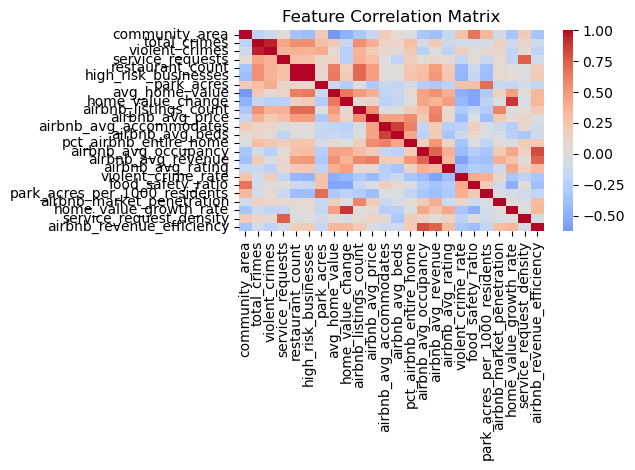

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = final_clean_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()

In [72]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\nHighly correlated features:")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} to {f2}: {r:.3f}")


Highly correlated features:
  total_crimes to violent_crimes: 0.946
  service_requests to service_request_density: 0.754
  restaurant_count to high_risk_businesses: 0.998
  restaurant_count to airbnb_listings_count: 0.703
  high_risk_businesses to airbnb_listings_count: 0.705
  park_acres to park_acres_per_1000_residents: 0.701
  home_value_change to home_value_growth_rate: 0.888
  airbnb_avg_accommodates to airbnb_avg_beds: 0.854
  airbnb_avg_occupancy to airbnb_avg_revenue: 0.734
  airbnb_avg_occupancy to airbnb_revenue_efficiency: 0.827
  airbnb_avg_revenue to airbnb_revenue_efficiency: 0.738


Total crime and violent crime are almost the same, so I stick with a rate measure. 311 requests and density tell a similar story. High-risk restaurants just scale with total restaurants, so I use a food safety ratio. Restaurants and Airbnb listings are correlated, as are high-risk restaurants and Airbnb, reflecting commercial density. Park acres vs scaled park acres are similar. Home value changes and growth rates track the same momentum, so I focus on growth. Airbnb accommodates vs beds, occupancy vs revenue, and revenue efficiency are all linked, showing these metrics capture the same underlying market strength. I will most likely remove some of these for the modeling.

####  VISUALIZATION 1

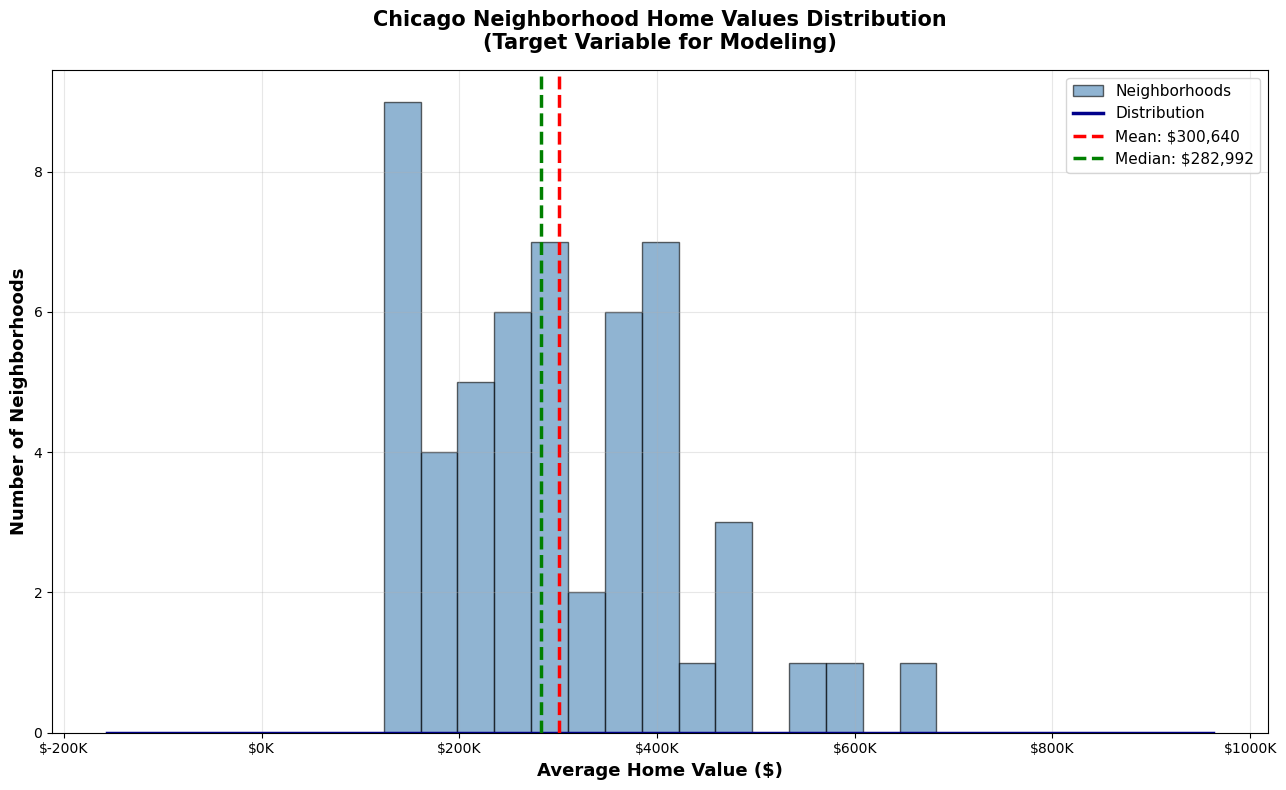

In [75]:
fig, ax = plt.subplots(figsize=(13, 8))

ax.hist(final_clean_df['avg_home_value'], bins=15, 
        color='steelblue', alpha=0.6, edgecolor='black', label='Neighborhoods')

final_clean_df['avg_home_value'].plot(kind='kde', ax=ax, color='darkblue', 
                                      linewidth=2.5, label='Distribution')

mean_val = final_clean_df['avg_home_value'].mean()
median_val = final_clean_df['avg_home_value'].median()

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: ${mean_val:,.0f}')
ax.axvline(median_val, color='green', linestyle='--', linewidth=2.5, 
           label=f'Median: ${median_val:,.0f}')

ax.set_xlabel('Average Home Value ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Neighborhoods', fontsize=13, fontweight='bold')
ax.set_title('Chicago Neighborhood Home Values Distribution\n(Target Variable for Modeling)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

The following figure displays average values for homes in Chicago's 53 community areas. The mean and median values are close. However, it's slightly skewed to the right due to a few high-value areas. Most values are between 200k and 400k. There are a few values over 500k. This tells me my target variable is continuous and will be fine for my forest regression and boosting.

#### VISUALIZATION 2

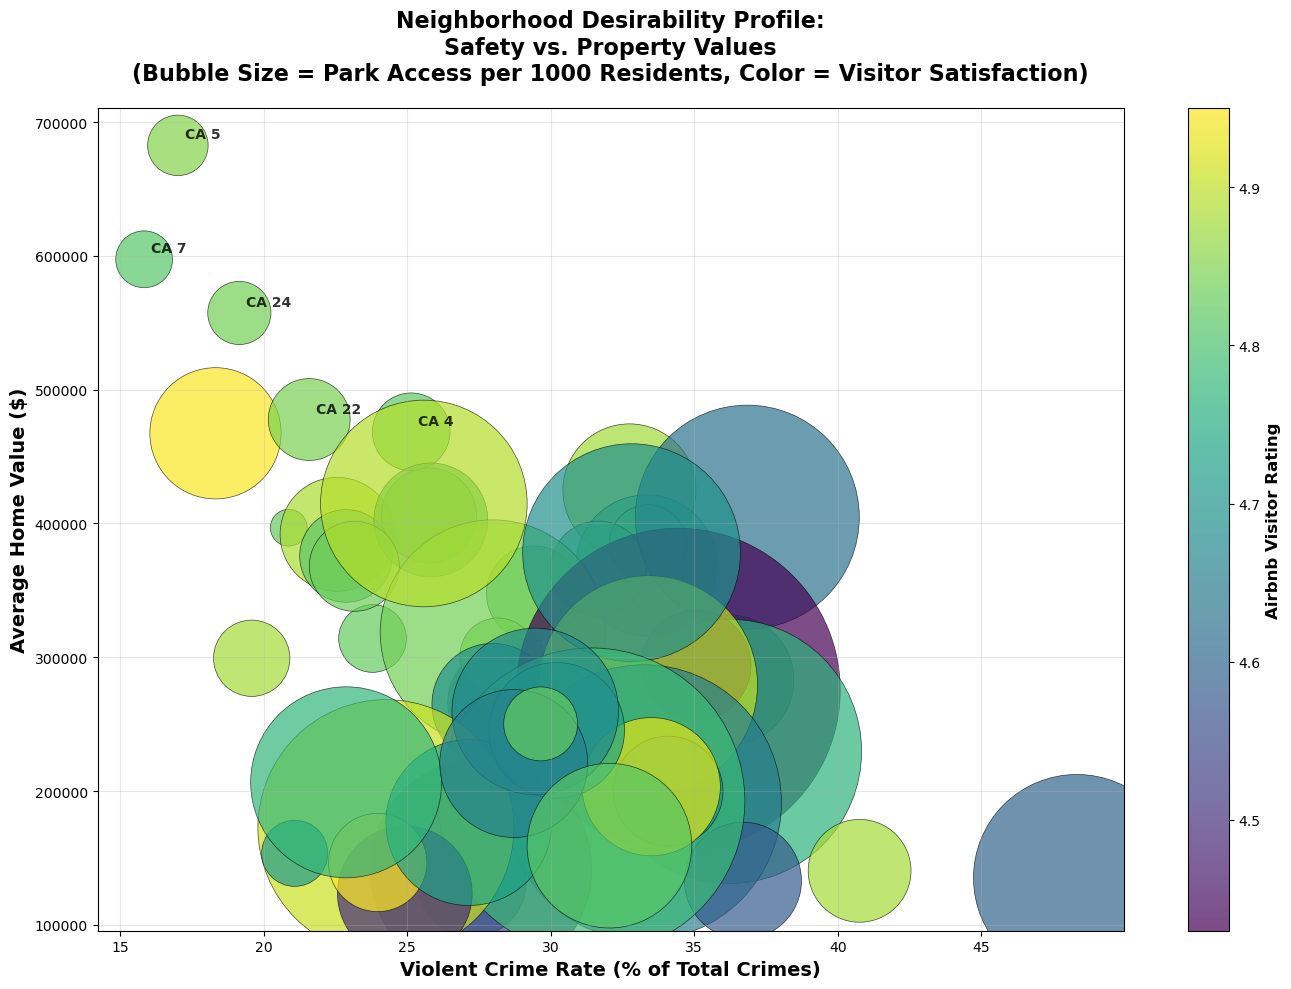

In [78]:
fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    final_clean_df['violent_crime_rate'],
    final_clean_df['avg_home_value'],
    s=final_clean_df['park_acres_per_1000_residents'] * 20,  # Bubble size = park access
    c=final_clean_df['airbnb_avg_rating'],  # Color = visitor satisfaction
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Violent Crime Rate (% of Total Crimes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Home Value ($)', fontsize=14, fontweight='bold')
ax.set_title('Neighborhood Desirability Profile:\nSafety vs. Property Values\n(Bubble Size = Park Access per 1000 Residents, Color = Visitor Satisfaction)', 
             fontsize=16, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Airbnb Visitor Rating', fontsize=12, fontweight='bold')

# Grid
ax.grid(True, alpha=0.3)

top_5 = final_clean_df.nlargest(5, 'avg_home_value')
for idx, row in top_5.iterrows():
    ax.annotate(
        f"CA {int(row['community_area'])}",
        (row['violent_crime_rate'], row['avg_home_value']),
        fontsize=10,
        fontweight='bold',
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In this bubble chart, the community areas are plotted with the violent crime rate on the x-axis and the average home value on the y-axis. I notice a general trend of a negative correlation between the two, meaning that areas with higher home values tend to have lower violent crime rates, though there are a number of outliers. The larger the bubble (indicating more access to parks), the better the home value, and the warmer the color (indicating higher ratings on Airbnb), the more desirable the area. The areas with the highest home values (CA 5, 7, 24) are plotted here as well.

### MODELING RANDOM FOREST

In [81]:
import time
from statistics import mode
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import numpy as np

In [82]:
y = final_clean_df['avg_home_value'].copy()

X = final_clean_df[[
    'service_request_density',
    'park_acres_per_1000_residents',
    'high_risk_businesses',
    'airbnb_avg_revenue',
    'airbnb_avg_rating',
    'violent_crime_rate',
    'food_safety_ratio',
    'home_value_growth_rate',
]].copy()

X = X.fillna(X.mean())

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

I used average home value as the response variable and eight interpretable features which span crime, service requests, access to parks, food risk, Airbnb performance, and recent home value growth. I fill missing values with column means to maintain all numeric data for tree-based models. I then split my data into a 75/25 split for training and testing with a set seed so that I may train on one set and test how well the model generalizes on unseen community areas.

In [84]:
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Train {len(X_train)/len(X)*100:.0f}%, Test {len(X_test)/len(X)*100:.0f}%")

print(f"Train target mean: ${y_train.mean():,.0f}, std: ${y_train.std():,.0f}")
print(f"Test target mean: ${y_test.mean():,.0f}, std: ${y_test.std():,.0f}")

Total samples: 53
Train samples: 39, Test samples: 14
Train 74%, Test 26%
Train target mean: $284,494, std: $111,379
Test target mean: $345,620, std: $160,078


These diagnostics demonstrate how the split was done and what the target variable looks like. There are 53 community areas, with 75% in the training set and 25% in the test set, which is a decent but still small sample size for machine learning. The test set has a larger and more variable mean home value, meaning it's a bit more expensive and varied.

In [86]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

depth =  2: Train R-squared = 0.4452, Test R-squared = 0.2189, Gap = 0.2263

depth =  3: Train R-squared = 0.4719, Test R-squared = 0.2283, Gap = 0.2437

depth =  4: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth =  5: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth =  6: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth =  7: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth =  8: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth =  9: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth = 10: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth = 11: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth = 12: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth = 13: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

depth = 14: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447


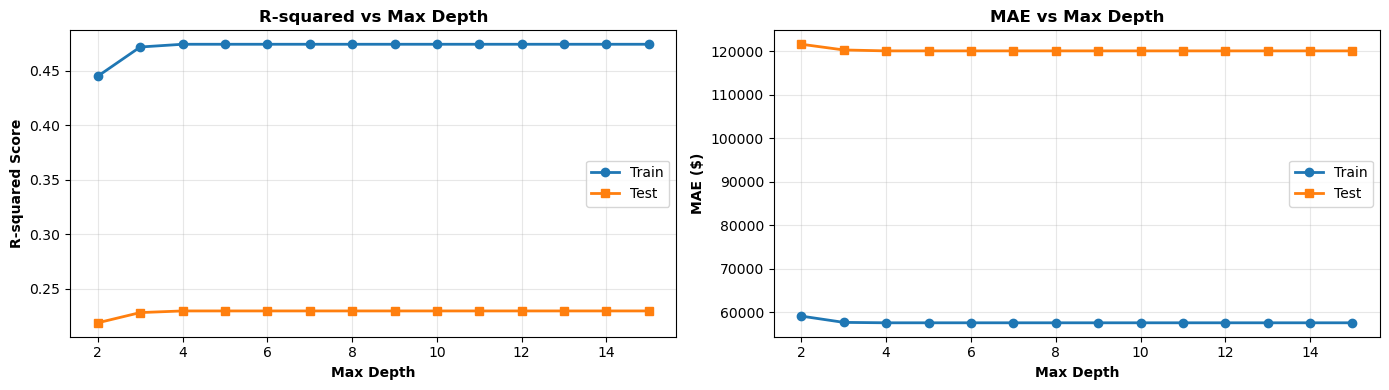

In [87]:
max_depths = range(2, 16)
train_r2, test_r2, train_mae, test_mae = [], [], [], []

for depth in max_depths:
    rf = RandomForestRegressor(n_estimators=50, max_depth=depth, min_samples_split=10, 
                               min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    tr2 = r2_score(y_train, rf.predict(X_train))
    vr2 = r2_score(y_test, rf.predict(X_test))
    train_r2.append(tr2)
    test_r2.append(vr2)
    train_mae.append(mean_absolute_error(y_train, rf.predict(X_train)))
    test_mae.append(mean_absolute_error(y_test, rf.predict(X_test)))
    
    print(f"depth = {depth:2d}: Train R-squared = {tr2:.4f}, Test R-squared = {vr2:.4f}, Gap = {tr2-vr2:.4f}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(max_depths, train_r2, 'o-', label='Train', linewidth=2, markersize=6)
ax1.plot(max_depths, test_r2, 's-', label='Test', linewidth=2, markersize=6)
ax1.set_xlabel('Max Depth', fontweight='bold')
ax1.set_ylabel('R-squared Score', fontweight='bold')
ax1.set_title('R-squared vs Max Depth', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(max_depths, train_mae, 'o-', label='Train', linewidth=2, markersize=6)
ax2.plot(max_depths, test_mae, 's-', label='Test', linewidth=2, markersize=6)
ax2.set_xlabel('Max Depth', fontweight='bold')
ax2.set_ylabel('MAE ($)', fontweight='bold')
ax2.set_title('MAE vs Max Depth', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_depth = list(max_depths)[test_r2.index(max(test_r2))]

I vary the Random Forest max depth from 2 to 15 while keeping everything else fixed. Training R-squared stays around 0.45–0.47 and test R-squared around 0.23, with a consistent gap of about 0.24. MAE shows the same pattern. This tells me that deeper trees do not improve generalization. The model is limited more by the small sample and feature set than by depth. Random Forest performance saturates quickly, so making trees deeper does not help capture neighborhood home value complexity.

n_est =  10: Train R-squared = 0.4894, Test R-squared = 0.3152, Gap = 0.1742

n_est =  20: Train R-squared = 0.4918, Test R-squared = 0.2244, Gap = 0.2674

n_est =  30: Train R-squared = 0.4838, Test R-squared = 0.2370, Gap = 0.2467

n_est =  40: Train R-squared = 0.4727, Test R-squared = 0.2415, Gap = 0.2312

n_est =  50: Train R-squared = 0.4745, Test R-squared = 0.2298, Gap = 0.2447

n_est =  60: Train R-squared = 0.4930, Test R-squared = 0.2628, Gap = 0.2302

n_est =  70: Train R-squared = 0.4834, Test R-squared = 0.2522, Gap = 0.2312

n_est =  80: Train R-squared = 0.4861, Test R-squared = 0.2613, Gap = 0.2248

n_est =  90: Train R-squared = 0.4827, Test R-squared = 0.2602, Gap = 0.2225

n_est = 100: Train R-squared = 0.4880, Test R-squared = 0.2734, Gap = 0.2146

n_est = 110: Train R-squared = 0.4911, Test R-squared = 0.2779, Gap = 0.2132

n_est = 120: Train R-squared = 0.4957, Test R-squared = 0.2838, Gap = 0.2120

n_est = 130: Train R-squared = 0.4958, Test R-squared = 0.2854, 

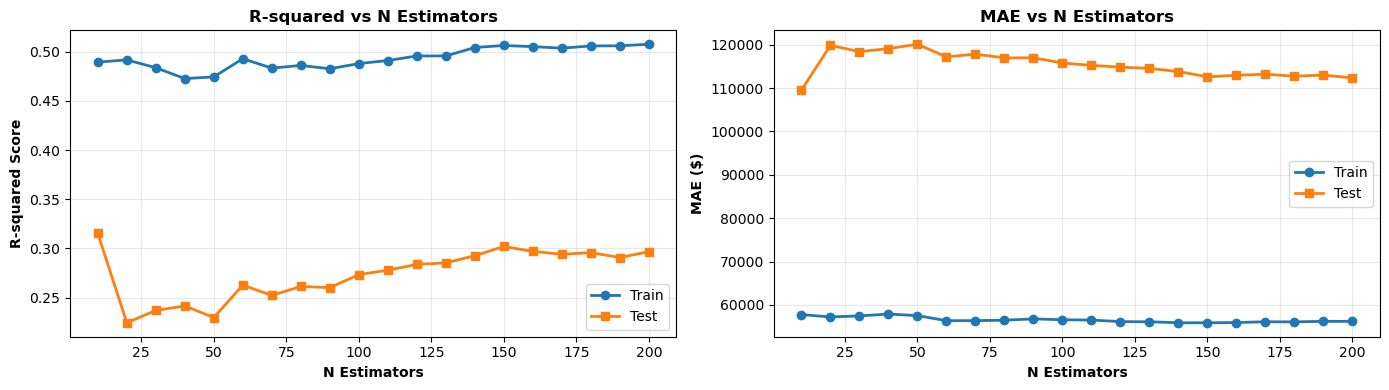

OPTIMAL N_ESTIMATORS
Optimal n_estimators: 10 (Test R-squared = 0.3152, MAE = $109,519)


In [89]:
n_estimators_range = range(10, 201, 10)
train_r2, test_r2, train_mae, test_mae = [], [], [], []

for n_est in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n_est, max_depth=5, min_samples_split=10, 
                               min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    tr2 = r2_score(y_train, rf.predict(X_train))
    vr2 = r2_score(y_test, rf.predict(X_test))
    train_r2.append(tr2)
    test_r2.append(vr2)
    train_mae.append(mean_absolute_error(y_train, rf.predict(X_train)))
    test_mae.append(mean_absolute_error(y_test, rf.predict(X_test)))
    
    print(f"n_est = {n_est:3d}: Train R-squared = {tr2:.4f}, Test R-squared = {vr2:.4f}, Gap = {tr2-vr2:.4f}\n")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(n_estimators_range, train_r2, 'o-', label='Train', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, test_r2, 's-', label='Test', linewidth=2, markersize=6)
ax1.set_xlabel('N Estimators', fontweight='bold')
ax1.set_ylabel('R-squared Score', fontweight='bold')
ax1.set_title('R-squared vs N Estimators', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(n_estimators_range, train_mae, 'o-', label='Train', linewidth=2, markersize=6)
ax2.plot(n_estimators_range, test_mae, 's-', label='Test', linewidth=2, markersize=6)
ax2.set_xlabel('N Estimators', fontweight='bold')
ax2.set_ylabel('MAE ($)', fontweight='bold')
ax2.set_title('MAE vs N Estimators', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_n_est = list(n_estimators_range)[test_r2.index(max(test_r2))]
optimal_mae = min(test_mae)

print("OPTIMAL N_ESTIMATORS")
print(f"Optimal n_estimators: {optimal_n_est} (Test R-squared = {max(test_r2):.4f}, MAE = ${optimal_mae:,.0f})")

I tested how Random Forest performance changes as I vary the number of trees from 10 to 200 while keeping everything else fixed. By tracking train and test R-squared and MAE, I can see if more trees improve generalization or just slightly reduce variance.

The plots show me that test set performance varies but does not get very high, and the gap between training and test R-squared remains relatively constant. This suggests to me that increasing the number of trees does not address the fundamental issues with Random Forest on this small dataset.

I will now choose the number of trees for Random Forest based on the best test set R-squared, which occurs at 10 trees. Even in this best case, test set R-squared is only about 0.32, with MAE about $110k. This confirms for me that Random Forest is explaining very little of the variation in home prices in the neighborhoods, in comparison to XGBoost.

In [91]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=10, max_depth=4, min_samples_split=10, 
                           min_samples_leaf=5, max_features='sqrt', oob_score=True, 
                           random_state=42, n_jobs=-1).fit(X_train, y_train)
t1 = time.time()

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

r2_tr = r2_score(y_train, y_train_pred)
mae_tr = mean_absolute_error(y_train, y_train_pred)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_te = r2_score(y_test, y_test_pred)
mae_te = mean_absolute_error(y_test, y_test_pred)
rmse_te = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Fit: {t1-t0:.2f}s\nTRAIN: R-squared = {r2_tr:.4f} MAE = ${mae_tr:,.0f} RMSE = ${rmse_tr:,.0f}\nOOB: R-squared = {rf.oob_score_:.4f}\nTEST: R-squared = {r2_te:.4f} MAE = ${mae_te:,.0f} RMSE = ${rmse_te:,.0f}\n")

Fit: 0.11s
TRAIN: R-squared = 0.4894 MAE = $57,779 RMSE = $78,557
OOB: R-squared = 0.1117
TEST: R-squared = 0.3152 MAE = $109,519 RMSE = $127,650



I refit the Random Forest using the best hyperparameters and check it more carefully. The model explains about 49% of the variance on the training set but only 31% on the test set, and the out-of-bag R-squared is around 0.11. This confirms that Random Forest is underfitting and struggling to capture the structure in such a small, noisy dataset.

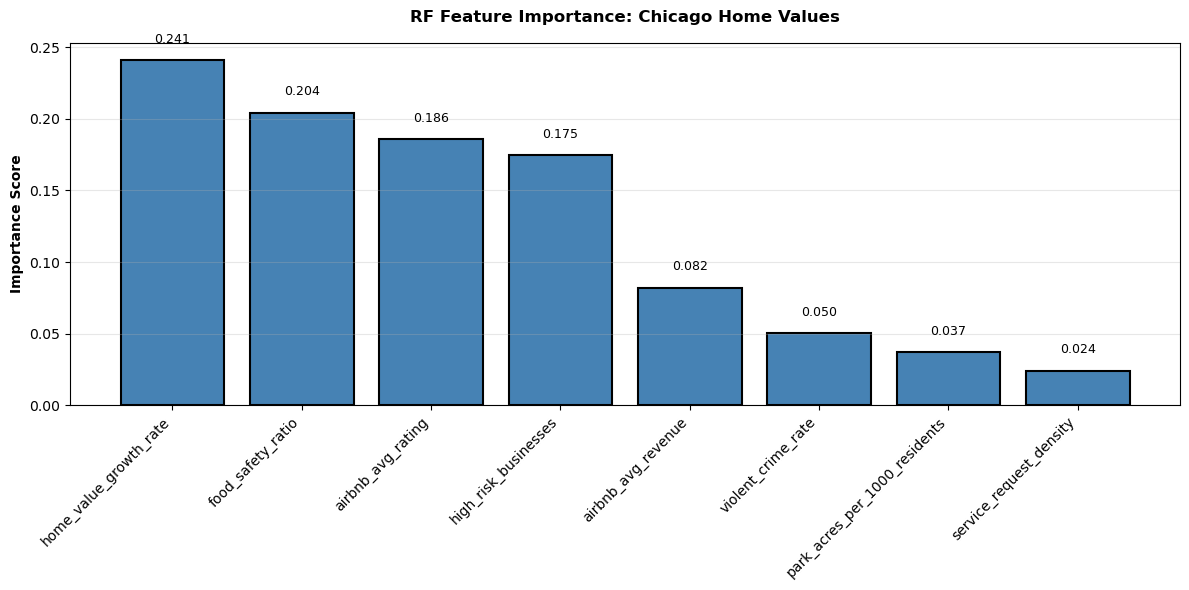

In [93]:
fi = pd.DataFrame({'Feature': feature_names, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(fi)), fi['Importance'], color='steelblue', edgecolor='black', linewidth=1.5)
plt.xticks(range(len(fi)), fi['Feature'], rotation=45, ha='right')
plt.ylabel('Importance Score', fontweight='bold')
plt.title('RF Feature Importance: Chicago Home Values', fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fi['Importance']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

This Random Forest feature importance plot shows how the weaker RF model sees drivers of home values. It leans most on home_value_growth_rate, then food_safety_ratio, followed by Airbnb_avg_rating and high_risk_businesses. Airbnb revenue, violent crime rate, park access, and service_request_density matter less, adding only modest refinements.

In [95]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"5-Fold CV R-squared: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV R-squared: 0.2778 ± 0.1006


The cross-validation shows that Random Forest explains about 28% of the variance on average, with a lot of fluctuation depending on which neighborhoods are held out. This confirms the signal is real but weak and unstable compared with the stronger, more consistent results I get with XGBoost.

#### XG BOOSTING

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2]
max_depths = [1, 2, 3, 4, 5]
n_estimators_range = [50, 100, 150, 200]

results = []

for lr in learning_rates:
    for depth in max_depths:
        for n_est in n_estimators_range:
            xgb = XGBRegressor(n_estimators=n_est, max_depth=depth, learning_rate=lr,
                               gamma=0.4, subsample=0.8, colsample_bytree=0.8, 
                               random_state=42, n_jobs=-1, verbosity=0)
            xgb.fit(X_train, y_train)
            
            r2_te = r2_score(y_test, xgb.predict(X_test))
            mae_te = mean_absolute_error(y_test, xgb.predict(X_test))
            
            results.append({
                'learning_rate': lr,
                'max_depth': depth,
                'n_estimators': n_est,
                'test_r2': r2_te,
                'test_mae': mae_te
            })
            
            print(f"lr = {lr:.2f}, depth = {depth}, n_est = {n_est:3d}: R-squared = {r2_te:.4f}, MAE = ${mae_te:,.0f}")

results_df = pd.DataFrame(results).sort_values('test_r2', ascending=False)
print("\nTOP 10 HYPERPARAMETER COMBINATIONS")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\n BEST: lr = {best['learning_rate']}, depth = {best['max_depth']}, n_est = {best['n_estimators']}")
print(f"  Test R-squared = {best['test_r2']:.4f}, MAE = ${best['test_mae']:,.0f}")

lr = 0.01, depth = 1, n_est =  50: R-squared = 0.0370, MAE = $139,281
lr = 0.01, depth = 1, n_est = 100: R-squared = 0.2120, MAE = $127,293
lr = 0.01, depth = 1, n_est = 150: R-squared = 0.3493, MAE = $116,896
lr = 0.01, depth = 1, n_est = 200: R-squared = 0.4406, MAE = $108,662
lr = 0.01, depth = 2, n_est =  50: R-squared = 0.0738, MAE = $136,101
lr = 0.01, depth = 2, n_est = 100: R-squared = 0.2321, MAE = $122,949
lr = 0.01, depth = 2, n_est = 150: R-squared = 0.3646, MAE = $112,803
lr = 0.01, depth = 2, n_est = 200: R-squared = 0.4505, MAE = $105,096
lr = 0.01, depth = 3, n_est =  50: R-squared = 0.0562, MAE = $137,215
lr = 0.01, depth = 3, n_est = 100: R-squared = 0.1987, MAE = $125,565
lr = 0.01, depth = 3, n_est = 150: R-squared = 0.3435, MAE = $114,860
lr = 0.01, depth = 3, n_est = 200: R-squared = 0.4338, MAE = $107,095
lr = 0.01, depth = 4, n_est =  50: R-squared = 0.0545, MAE = $137,430
lr = 0.01, depth = 4, n_est = 100: R-squared = 0.1983, MAE = $125,871
lr = 0.01, depth = 4

In this grid search, I’m trying different settings for XGBoost’s learning rate, tree depth, and number of trees. If the learning rate is very low, it learns very slowly and doesn’t do great, but if it’s around 0.05 to 0.10, it really takes off. If the tree depth is low with 100 to 200 trees, it still scores really well in the mid-0.6s for R-squared and 70 to 90k for MAE. Increasing the trees much beyond 150 doesn’t really do much, so the best approach seems to be a shallow model with a moderate tree count and a moderate learning rate around 0.10 to 0.15. The best combination seems to be a 0.15 for the learning rate, depth of 1, and 200 trees, with a test R-squared value at 0.71 and an MAE value at $67k, far outperforming

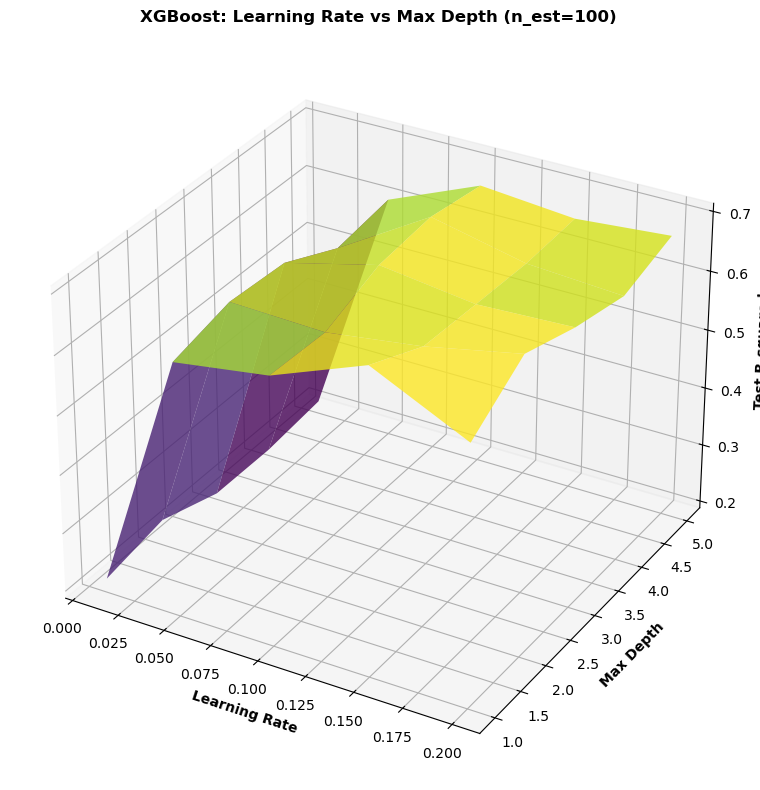

In [100]:
subset = results_df[results_df['n_estimators'] == 100].pivot_table(
    index='max_depth', columns='learning_rate', values='test_r2'
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X_lr = subset.columns.values
Y_depth = subset.index.values
X_lr_grid, Y_depth_grid = np.meshgrid(X_lr, Y_depth)
Z = subset.values

ax.plot_surface(X_lr_grid, Y_depth_grid, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('Learning Rate', fontweight='bold')
ax.set_ylabel('Max Depth', fontweight='bold')
ax.set_zlabel('Test R-squared', fontweight='bold')
ax.set_title('XGBoost: Learning Rate vs Max Depth (n_est=100)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('xgb_surface_lr_depth.png', dpi=300, bbox_inches='tight')
plt.show()


On this graph, I’m setting XGBoost to 100 trees and examining the test R-squared’s response to changes in the learning rate and tree depth. Low learning rates underperform regardless of tree depth. The performance increases rapidly over 0.05 to 0.15 before plateauing, especially when tree depth is shallow (1-3). This demonstrates that moderate-aggressive learning with basic tree depth is effective, and deeper trees are unnecessary.

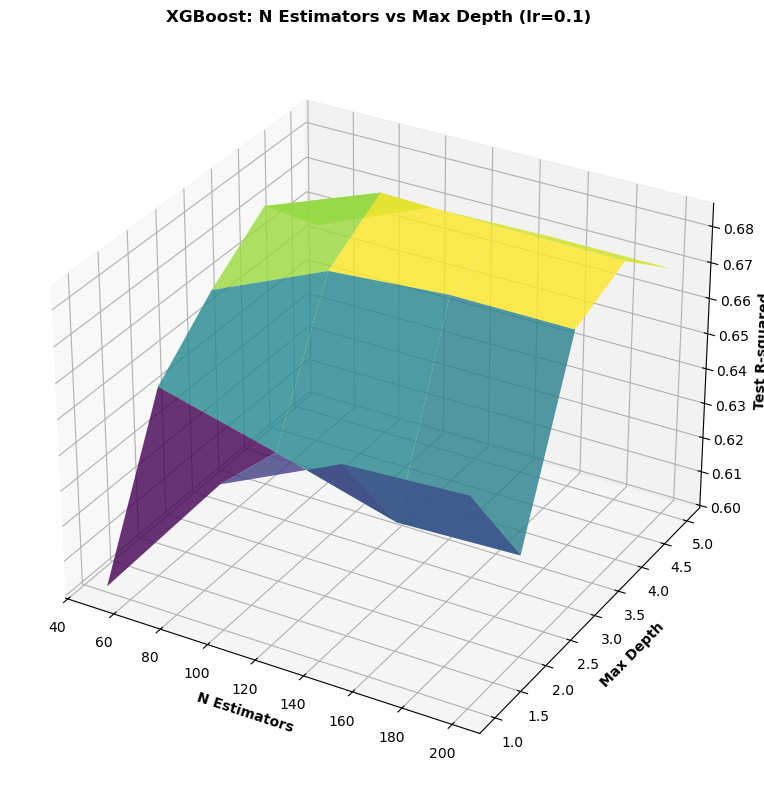

In [102]:
subset = results_df[results_df['learning_rate'] == 0.1].pivot_table(
    index='max_depth', columns='n_estimators', values='test_r2'
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X_est = subset.columns.values
Y_depth = subset.index.values
X_est_grid, Y_depth_grid = np.meshgrid(X_est, Y_depth)
Z = subset.values

ax.plot_surface(X_est_grid, Y_depth_grid, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('N Estimators', fontweight='bold')
ax.set_ylabel('Max Depth', fontweight='bold')
ax.set_zlabel('Test R-squared', fontweight='bold')
ax.set_title('XGBoost: N Estimators vs Max Depth (lr=0.1)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('xgb_surface_est_depth.png', dpi=300, bbox_inches='tight')
plt.show()


In this figure I focus on how XGBoost behaves when I fix the learning rate at 0.1 and vary only two things: the number of trees and their maximum depth. The surface shows that performance (test R-squared) improves quickly as I move away from very small, shallow models, but then flattens into a broad plateau where adding more trees or extra depth yields almost no additional gain. That plateau tells me there is a wide region of “good enough” settings around moderate depth and roughly 100–150 trees, and that pushing the model to be deeper or much larger at this learning rate mostly increases computation rather than accuracy.

In [104]:
xgb_final = XGBRegressor(
    n_estimators=200,
    max_depth=1,
    learning_rate=0.15,
    gamma=1.0,
    subsample=0.6,
    colsample_bytree=0.6,
    early_stopping_rounds=10,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# FIT THE MODEL
xgb_final.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# NOW predict
y_pred_train = xgb_final.predict(X_train)
y_pred_test = xgb_final.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("FINAL MODEL PERFORMANCE")
print(f"Training R-squared: {r2_train:.4f}")
print(f"Test R-squared: {r2_test:.4f}")
print(f"Test MAE: ${mae_test:,.0f}")
print(f"Test RMSE: ${rmse_test:,.0f}")
print(f"Train-Test Gap: {(r2_train - r2_test)*100:.1f}%")

FINAL MODEL PERFORMANCE
Training R-squared: 0.7737
Test R-squared: 0.7087
Test MAE: $65,574
Test RMSE: $83,250
Train-Test Gap: 6.5%


I lock in the best XGBoost hyperparameters, 200 trees, depth 1, learning rate 0.15, with subsampling and column sampling, and train on the full set with early stopping. The model explains about 77 percent of variance on training data and 71 percent on the test set, a big improvement over Random Forest. Test MAE is around 65,600 and RMSE about 83,300, so predictions are usually within 65k of the true values. The small R-squared gap of 6.5 points shows the model captures real signal without overfitting, making it my go-to for interpreting neighborhood desirability.

In [106]:
xgb_cv = XGBRegressor(
    n_estimators=200,
    max_depth=1,
    learning_rate=0.05,
    gamma=1,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_scores_xgb = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='r2')
print(f"XGBoost 5-Fold CV R-squared: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

XGBoost 5-Fold CV R-squared: 0.2110 ± 0.2258


This 5-fold cross-validation indicates that, on average for different splits of the training data, XGBoost is able to account for 21 percent of the variance in home prices, but the standard deviation is large at approximately 0.23. This means that the performance is very variable depending on which community areas are left out of the training data, which is what I would expect given that there are only 39 training observations. I take this as a warning that while my model appears to be very good on the train/test split that I have chosen, the actual out-of-sample performance is more variable, and I will report the findings as indicative trends rather than the most precise predictions.

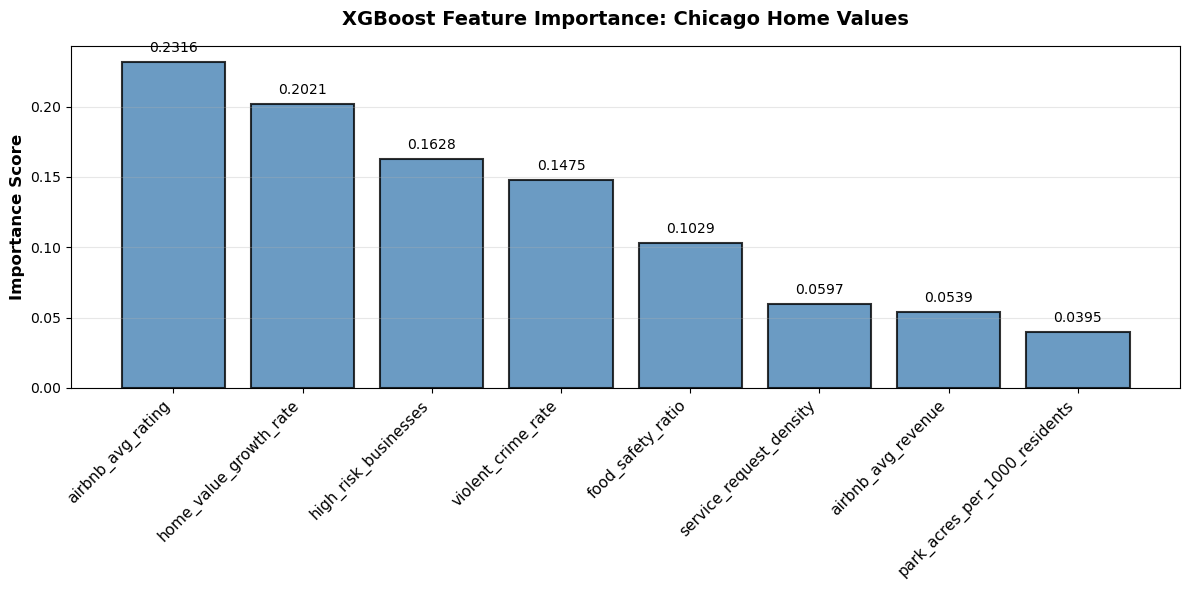

In [108]:
fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
top_n = 10
top_fi = fi.head(top_n)

bars = plt.bar(range(len(top_fi)), top_fi['Importance'].values, 
               color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(top_fi)), top_fi['Feature'].values, rotation=45, ha='right', fontsize=11)
plt.ylabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('XGBoost Feature Importance: Chicago Home Values', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, top_fi['Importance'].values)):
    plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

This feature importance chart illustrates the factors my final XGBoost model used most in determining neighborhood home values. Average Airbnb rating is first, indicating that guest satisfaction with short-term rentals is strongly related to home values. Recent home value appreciation is second, indicating that rapidly appreciating neighborhoods are more valuable. High-risk business density and violent crime rate are third and fourth, respectively, indicating that safety and commercial risk are factors that decrease home values. Food safety ratio, service request density, Airbnb revenue, and park access per 1,000 residents all provide smaller but still important adjustments.